## Imports

In [ ]:
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)
print(sys.path)

# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import random
import csv

# Import your modules
from proto_language.program import Program
from proto_language.generator import MCMCGenerator, Evo2Generator
from proto_language.constraint import sequence_length_constraint, gc_content_constraint, max_homopolymer_constraint, dinucleotide_frequency_constraint, tetranucleotide_usage_constraint, orfipy_mmseqs_gene_hit_count_constraint, orfipy_mmseqs_gene_homology_constraint
from proto_language.base import Constraint, Construct, ConstructSegment, SequenceType, Sequence

random.seed(42)
np.random.seed(42)

## Modify Evo2 Repo to load EvoPhage finetuned checkpoint

In [6]:
from evo2.utils import MODEL_NAMES, CONFIG_MAP

MODEL_NAMES.append("evo2_7b_phage_12k_gen")
CONFIG_MAP["evo2_7b_phage_12k_gen"] = 'configs/config.yaml'

## Write Program


In [7]:
NUM_MCMC_STEPS = 3 # Number of MCMC steps to run
MIN_GC = 35  # Min target for high GC content (%)
MAX_GC = 65  # Max target for high GC content (%)
MAX_HOMOPOLYMER = 10
MIN_FREQ = 0
MAX_FREQ = 20
TETRANUCLEOTIDE = "GATC"
MIN_TUD = 0
MAX_TUD = 1
MIN_GENE_HITS = 10  # Min target for gene hits
MAX_GENE_HITS = 12  # Max target for gene hits
TRACK_EVERY = 1

#######################
## ConstructSegments ##
#######################

segment = ConstructSegment(
    sequence_type=SequenceType.DNA,
    valid_chars=set("ATCG+~ "),
)

###############
## Generator ##
###############

# Initialize ProgramGenerator
evo2_generator = Evo2Generator(
    prompt_seqs=["+~GAGTTTTA"],
    evo2_type="evo2_7b_phage_12k_gen",
    evo2_local_path="/scratch/hielab/gbrixi/evo2/vortex_interleaved/7b_phage/iter_12000.pt",
    sequence_length=5500,
    temperature=0.9,
    batch_size=10,
    prepend_prompt=True,
)

evo2_generator.assign(segment)

################
## Construct ##
################

construct = Construct([segment])

#################
## Constraints ##
#################

sequence_length = Constraint(
    inputs=[segment],
    scoring_function=sequence_length_constraint,
    scoring_function_config={"target_length": 5386}
)

gc_content = Constraint(
    inputs=[segment],
    scoring_function=gc_content_constraint,
    scoring_function_config={"min_gc": MIN_GC, "max_gc": MAX_GC}
)

max_homopolymer = Constraint(
    inputs=[segment],
    scoring_function=max_homopolymer_constraint,
    scoring_function_config={"max_length": MAX_HOMOPOLYMER}
)

dinucleotide_frequency = Constraint(
    inputs=[segment],
    scoring_function=dinucleotide_frequency_constraint,
    scoring_function_config={"min_freq": MIN_FREQ, "max_freq": MAX_FREQ}
)

tetranucleotide_usage = Constraint(
    inputs=[segment],
    scoring_function=tetranucleotide_usage_constraint,
    scoring_function_config={"tetranucleotide": TETRANUCLEOTIDE, "min_tud": MIN_TUD, "max_tud": MAX_TUD}
)

gene_hit_count_config = {
    "min_hits": MIN_GENE_HITS,
    "max_hits": MAX_GENE_HITS,
    "mmseqs_kwargs": {
        "database": "/large_storage/hielab/samuelking/phrogs/phrogs_mmseqs_db/phrogs_mmseqs_db",
        "threads": 96,
        "sensitivity": 4.0
    },
    "orfipy_kwargs": {
        "threads": 96,
        "min_len": 30,
        "max_len": 5500
    }
}
gene_hit_count = Constraint(
    inputs=[segment],
    scoring_function=orfipy_mmseqs_gene_hit_count_constraint,
    scoring_function_config=gene_hit_count_config
)

gene_homology_config = {
    "min_homology": 80.0,  # Minimum 80% homology
    "max_homology": 100.0,  # Maximum 100% homology
    "mmseqs_kwargs": {
        "database": "/large_storage/hielab/samuelking/phrogs/phrogs_mmseqs_db/phrogs_mmseqs_db",
        "threads": 96,
        "sensitivity": 4.0
    },
    "orfipy_kwargs": {
        "threads": 96,
        "min_len": 30,
        "max_len":5500
    }
}
gene_homology = Constraint(
    inputs=[segment],
    scoring_function=orfipy_mmseqs_gene_homology_constraint,
    scoring_function_config=gene_homology_config
)

#############
## Program ##
#############

# Initialize Program with correct sequence_order type
program = Program(
    iterative_generator_type=MCMCGenerator,
    constructs=[construct],
    generators=[evo2_generator],
    constraints=[
        sequence_length,
        gc_content,
        max_homopolymer,
        dinucleotide_frequency,
        tetranucleotide_usage,
        gene_hit_count,
        gene_homology,
    ],
    num_steps=NUM_MCMC_STEPS,
    track_step_size=TRACK_EVERY,
)

Using cached Evo2 model with key: evo2_7b_phage_12k_gen:/scratch/hielab/gbrixi/evo2/vortex_interleaved/7b_phage/iter_12000.pt


## Run Program

In [8]:
initial_construct = program.ebm.constructs[0]
program.run()
print(f"Generated {len(program.history)} sequence snapshots during optimization")
final_construct = program.ebm.constructs[0]

Initial constructs for all batch elements:
  Construct 0:
    Batch 0:  (energy: N/A)
    Batch 1:  (energy: N/A)
    Batch 2:  (energy: N/A)
    Batch 3:  (energy: N/A)
    Batch 4:  (energy: N/A)
    Batch 5:  (energy: N/A)
    Batch 6:  (energy: N/A)
    Batch 7:  (energy: N/A)
    Batch 8:  (energy: N/A)
    Batch 9:  (energy: N/A)
[orfipy] Running: orfipy /tmp/tmpygzppmbn/input.fasta --procs 96 --start ATG --stop TAA,TAG,TGA --strand b --min 30 --max 5500 --dna /tmp/tmpygzppmbn/orfipy_output/orfipy_nt.fna --pep /tmp/tmpygzppmbn/orfipy_output/orfipy_aa.faa --outdir /tmp/tmpygzppmbn/orfipy_output --include-stop
[orfipy] Running: orfipy /tmp/tmplhb4uqgu/input.fasta --procs 96 --start ATG --stop TAA,TAG,TGA --strand b --min 30 --max 5500 --dna /tmp/tmplhb4uqgu/orfipy_output/orfipy_nt.fna --pep /tmp/tmplhb4uqgu/orfipy_output/orfipy_aa.faa --outdir /tmp/tmplhb4uqgu/orfipy_output --include-stop
[orfipy] Running: orfipy /tmp/tmpohyummuh/input.fasta --procs 96 --start ATG --stop TAA,TAG,TG

In [9]:
print(f"Final sequence: {final_construct.batch_sequences[0].sequence}")
print(f"Final sequence length: {len(final_construct.batch_sequences[0].sequence)}")
print(f"Final energy: {program.ebm.score_energy()}")

Final sequence: +~GAGTTTTATCGCTTCCATGACGCAGAAGTTAACACTTTCGGATATTTCTGATGAGTCGAAAAATTATCTTGATAAAGCAGGAATTACTACTGCTTGTTTACGAATTAAATCGAAGTGGACTGCTGGCGGAAAATGAGAAAATTCGACCTATCCTTGCGCAGCTCGAGAAGCTCTTACTTTGCGACCTTTCGCCATCAACTAACGATTCTGTCAAAAACTGACGCGTTGGATGAGGAGAAGTGGCTTAATATGCTTGGCACGTTCGTTAAGGACTGGTTTAGATATGAGTCACATTTTGTTCACGGTAGAGATTCTCTTGTTGACATTTTAAAAGAGCGTGGATTACTATCTGAGTCCGATGCTGTTCAACCACTAATAGGTAAAAAATCATGAGTCAAGTTACTGAACAATCTGTACGTTTCCAGACTGCGCTGGCCTCCATTAAGCTGATTCAGGCTTCTGCCGTTTTGGATTTAACCGAAGATGATTTCGATTTTCTGACGAGTAACAAGGTTTGGATTGCTACTGACCGCTCTCGTGCTCGTCGCTGCGTTGAGGCTTGCGTTTATGGTACGCTGGACTTTGTGGGATACCCTCGCTTTCCTGCTCCTGTTGAGTTTATTGCTGCCGTCATTGCTTATTATGTTCATCCCGTCAACATTCAAACGGCCTGCCTCATCATGGAAGGCGCTGAATTTACGGAAAACATTATTAATGGCGTCGAGCGTCCGGTTAAAGCCGCTGAACTGTTCGCGTTTACCCTGCGTGTACGCGCAGGAAACACTGACGTTCTTACTGATGCAGAAGAGAACGTCCGCCAAAAATTACGCGCAGAAGGAGTGATGTAATGTCTAAAGGTAAAAAGCGTTCTGGCGCTCGCCCCGGTCGTCCACAGCCGTTGCGAGGCACTAAAGGCAAGCGCAAAGGTGCTCGCCTCTGGTATGTAGGTGGTCAACAATTTTAATTATAGGGGCTTCGGCCC

## Export metadata as CSV

In [10]:
metadata = final_construct.batch_sequences[0]._metadata
print(metadata)
with open('metadata_examples/evo2_phage_metadata.csv', 'w') as f:
    writer = csv.DictWriter(f, fieldnames=metadata.keys())
    writer.writeheader()
    writer.writerow(metadata)

{'sequence': '+~GAGTTTTATCGCTTCCATGACGCAGAAGTTAACACTTTCGGATATTTCTGATGAGTCGAAAAATTATCTTGATAAAGCAGGAATTACTACTGCTTGTTTACGAATTAAATCGAAGTGGACTGCTGGCGGAAAATGAGAAAATTCGACCTATCCTTGCGCAGCTCGAGAAGCTCTTACTTTGCGACCTTTCGCCATCAACTAACGATTCTGTCAAAAACTGACGCGTTGGATGAGGAGAAGTGGCTTAATATGCTTGGCACGTTCGTTAAGGACTGGTTTAGATATGAGTCACATTTTGTTCACGGTAGAGATTCTCTTGTTGACATTTTAAAAGAGCGTGGATTACTATCTGAGTCCGATGCTGTTCAACCACTAATAGGTAAAAAATCATGAGTCAAGTTACTGAACAATCTGTACGTTTCCAGACTGCGCTGGCCTCCATTAAGCTGATTCAGGCTTCTGCCGTTTTGGATTTAACCGAAGATGATTTCGATTTTCTGACGAGTAACAAGGTTTGGATTGCTACTGACCGCTCTCGTGCTCGTCGCTGCGTTGAGGCTTGCGTTTATGGTACGCTGGACTTTGTGGGATACCCTCGCTTTCCTGCTCCTGTTGAGTTTATTGCTGCCGTCATTGCTTATTATGTTCATCCCGTCAACATTCAAACGGCCTGCCTCATCATGGAAGGCGCTGAATTTACGGAAAACATTATTAATGGCGTCGAGCGTCCGGTTAAAGCCGCTGAACTGTTCGCGTTTACCCTGCGTGTACGCGCAGGAAACACTGACGTTCTTACTGATGCAGAAGAGAACGTCCGCCAAAAATTACGCGCAGAAGGAGTGATGTAATGTCTAAAGGTAAAAAGCGTTCTGGCGCTCGCCCCGGTCGTCCACAGCCGTTGCGAGGCACTAAAGGCAAGCGCAAAGGTGCTCGCCTCTGGTATGTAGGTGGTCAACAATTTTAATTATAGGGGCTTCGGCCCCT

## Visualize Optimization

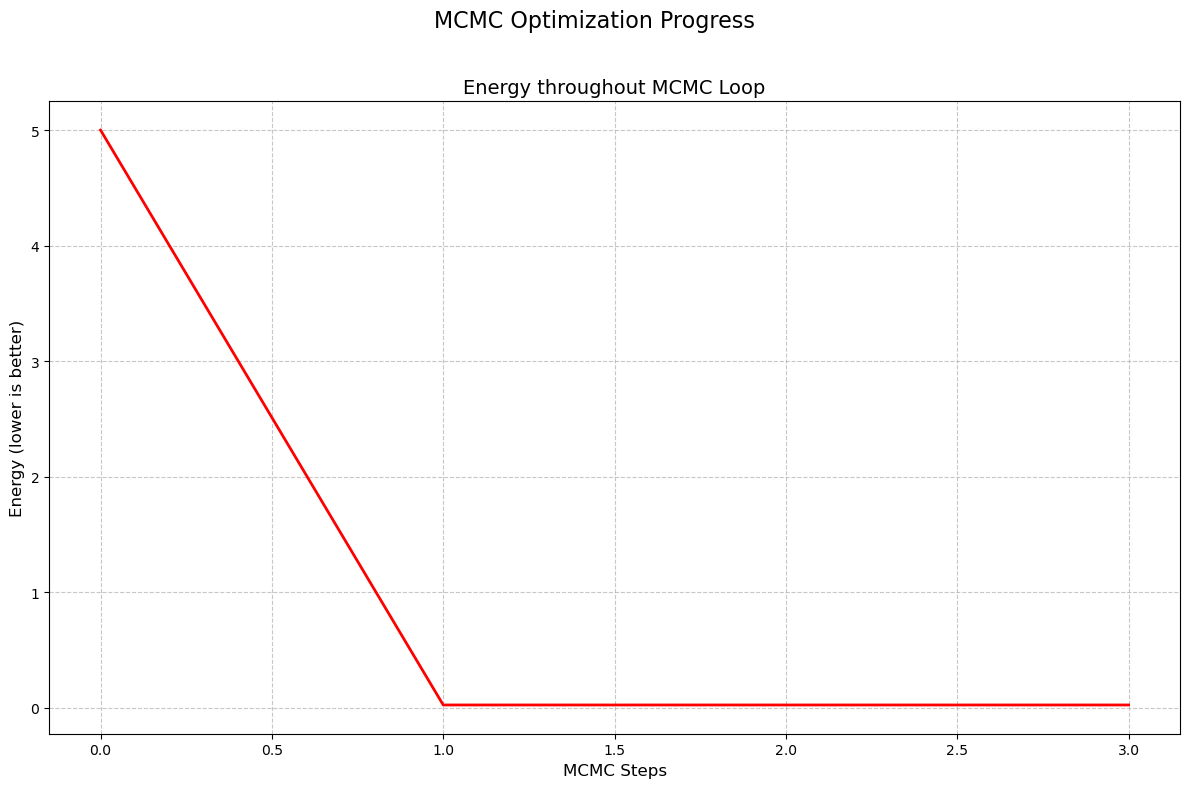

In [12]:
energy_history = [construct[0].batch_sequences[0]._metadata['energy_score'] for construct in program.history]
steps_history = [construct[0].batch_sequences[0]._metadata["time_step"] for construct in program.history]

# Energy evolution
plt.figure(figsize=(12, 8))
plt.plot(steps_history, energy_history, 'r-', linewidth=2)
plt.xlabel('MCMC Steps', fontsize=12)
plt.ylabel('Energy (lower is better)', fontsize=12)
plt.title('Energy throughout MCMC Loop', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tick_params(labelsize=10)

# Add a main title for the entire figure
plt.suptitle('MCMC Optimization Progress', fontsize=16, y=0.98)

# Save the figure
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for suptitle
plt.show()

## Compare EvoPhage to PhiX174 Reference Genome

In [13]:
# Sequence alignment and text-based visualization using biotite

import biotite.sequence as seq
import biotite.sequence.align as align
from Bio import SeqIO

def calculate_pident_to_ref(query_sequence: str, reference_sequence: str) -> float:
    """Calculates % sequence identity to reference sequence using global alignment."""

    # Ensure sequences are uppercase and remove any unexpected whitespaces
    query_sequence = query_sequence.replace("*", "").upper().strip()
    reference_record = next(SeqIO.parse(reference_sequence, "fasta"))
    reference_sequence = str(reference_record.seq).upper().strip()

    # Check sequences for unexpected characters
    valid_nucleotides = set("ACGT")
    if any(char not in valid_nucleotides for char in query_sequence) or any(char not in valid_nucleotides for char in reference_sequence):
        raise ValueError(f"Invalid character in query or reference sequence: {query_sequence}, {reference_sequence}")

    matrix = align.SubstitutionMatrix.std_nucleotide_matrix()
    query = seq.NucleotideSequence(query_sequence)
    ref = seq.NucleotideSequence(reference_sequence)
    alignments = align.align_optimal(query, ref, matrix, terminal_penalty=False) # Default is global alignment (based on Needleman-Wunsch algorithm)

    # Calculate sequence identity
    seq_ident = align.get_pairwise_sequence_identity(alignments[0])
    return seq_ident[0][1] * 100, alignments[0]

# Calculate sequence identity and get alignment
final_sequence = final_construct.batch_sequences[0].sequence[2:].split()[0]
reference_path = "../data/phix_genome.fasta"

print(f"Final sequence length: {len(final_sequence)}")

# Calculate identity using the provided function
print("\nPerforming global alignment using biotite...")
identity_percent, alignment = calculate_pident_to_ref(final_sequence, reference_path)

# Get the alignment sequences for visualization
aligned_query_str = str(alignment.sequences[0])
aligned_ref_str = str(alignment.sequences[1])

print(f"Alignment score: {alignment.score}")
print(f"Aligned sequence length: {len(aligned_ref_str)}")

# Calculate alignment statistics
matches = sum(1 for a, b in zip(aligned_query_str, aligned_ref_str) if a == b and a != '-' and b != '-')
mismatches = sum(1 for a, b in zip(aligned_query_str, aligned_ref_str) if a != b and a != '-' and b != '-')
gaps = sum(1 for a, b in zip(aligned_query_str, aligned_ref_str) if a == '-' or b == '-')

print("\nAlignment Statistics:")
print(f"Total aligned length: {len(aligned_ref_str)}")
print(f"Matches: {matches}")
print(f"Mismatches: {mismatches}")
print(f"Gaps: {gaps}")
print(f"Sequence identity: {identity_percent:.2f}%")

# Text-based alignment visualization
def print_alignment_text(seq1, seq2, seq1_name="Reference", seq2_name="Generated", line_length=150):
    """Print sequences in traditional alignment format with | for matches"""
    print(f"\n{'='*80}")
    print("TEXT-BASED ALIGNMENT")
    print(f"{'='*80}")
    print(f"Alignment length: {len(seq1)} positions")
    print(f"Line length: {line_length} characters\n")
    
    for i in range(0, len(seq1), line_length):
        end_pos = min(i + line_length, len(seq1))
        
        # Get sequence segments
        seg1 = seq1[i:end_pos]
        seg2 = seq2[i:end_pos]
        
        # Create alignment string (| for match, . for mismatch, space for gap)
        alignment = ''
        for a, b in zip(seg1, seg2):
            if a == '-' or b == '-':
                alignment += ' '  # Gap
            elif a == b:
                alignment += '|'  # Match
            else:
                alignment += '.'  # Mismatch
        
        # Print block with position numbers
        print(f"Position {i+1:>6}-{end_pos:<6}")
        print(f"{seq1_name:>10}: {seg1}")
        print(f"{'':>10}  {alignment}")
        print(f"{seq2_name:>10}: {seg2}")
        print()

# Print the alignment
print_alignment_text(aligned_ref_str, aligned_query_str, "PhiX174", "EvoPhage")


Final sequence length: 5508

Performing global alignment using biotite...
Alignment score: 25546
Aligned sequence length: 5386

Alignment Statistics:
Total aligned length: 5386
Matches: 5232
Mismatches: 154
Gaps: 0
Sequence identity: 97.16%

TEXT-BASED ALIGNMENT
Alignment length: 5386 positions
Line length: 150 characters

Position      1-150   
   PhiX174: GAGTTTTATCGCTTCCATGACGCAGAAGTTAACACTTTCGGATATTTCTGATGAGTCGAAAAATTATCTTGATAAAGCAGGAATTACTACTGCTTGTTTACGAATTAAATCGAAGTGGACTGCTGGCGGAAAATGAGAAAATTCGACCTA
            ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
  EvoPhage: GAGTTTTATCGCTTCCATGACGCAGAAGTTAACACTTTCGGATATTTCTGATGAGTCGAAAAATTATCTTGATAAAGCAGGAATTACTACTGCTTGTTTACGAATTAAATCGAAGTGGACTGCTGGCGGAAAATGAGAAAATTCGACCTA

Position    151-300   
   PhiX174: TCCTTGCGCAGCTCGAGAAGCTCTTACTTTGCGACCTTTCGCCATCAACTAACGATTCTGTCAAAAACTGACGCGTTGGATGAGGAGAAGTGGCTTAATATGCTTGGCACGTTCGTCAAGGACTGGT